In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import sys
import statsmodels.api as sm
import seaborn as sns
sys.path.insert(0, "../..")
from src.helper_functions.helper_functions import set_index, calc_yearly_percent_change, calc_yearly_change

In [ ]:
#read in cleaned immmigration and population dataframes and set year as index
immigration_pop = pd.read_csv("../../data/clean/immigration_data/foreign_resident_pop_2012-2024.csv")
immigration_rate = pd.read_csv("../../data/clean/immigration_data/foreign_resident_yearly_inc_2012-2024.csv")
total_pop = pd.read_csv("../../data/clean/immigration_data/japan_pop_2012-2024.csv")

immigration_pop = set_index(immigration_pop, 'year')
immigration_rate = set_index(immigration_rate, 'year')
total_pop = set_index(total_pop, 'year')

In [5]:
#make new dataframe for percent of prefecture population that is foreign resident
immigrant_pop_percent = immigration_pop.copy()
for column in immigrant_pop_percent.columns:
    immigrant_pop_percent[column] = immigration_pop[column] / total_pop[column]


In [6]:
#get mean immigration population percent over time and plot
means = immigrant_pop_percent.describe().loc['mean']
means.sort_values(inplace=True)

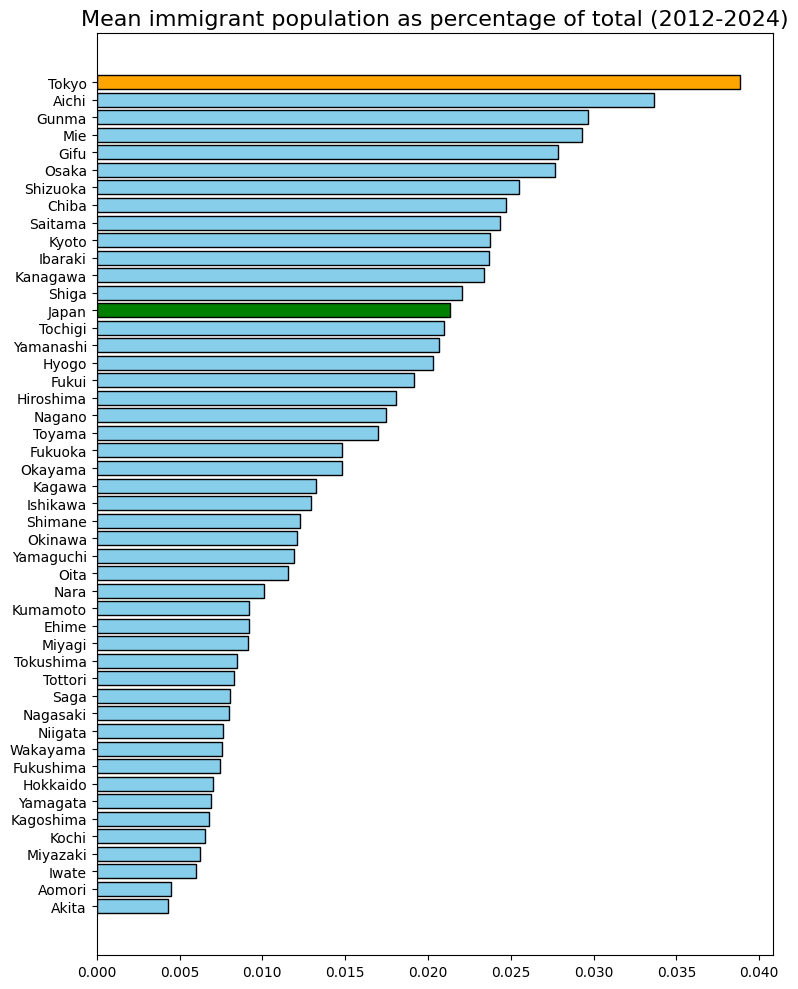

In [ ]:
#plt.bar(means.index, means to visualize mean immigrant population in various prefectures
highlight = {'Tokyo':'orange', 'Japan':'green'}
colors = [highlight.get(name, 'skyblue') for name in means.index]

fig, ax = plt.subplots(figsize=(8,10))
ax.barh(means.index, means, color = colors, edgecolor='black')
ax.set_title('Mean immigrant population as percentage of total (2012-2024)', fontsize=16)
#ax.set_ylabel('Mean yearly increase')
#ax.set_xticks(range(len(means.index)))
#ax.set_xticklabels(means.index, rotation=90)
fig.tight_layout()
plt.show()

In [ ]:
#create a dataframe with the yearly increase of immigrant percent population
imm_pop_percent_yearly_inc = immigrant_pop_percent.copy()
for column in imm_pop_percent_yearly_inc.columns:
    imm_pop_percent_yearly_inc[column] = calc_yearly_change(imm_pop_percent_yearly_inc[column])

/var/folders/bc/ckv226vd2r767mrgsjn26yn80000gn/T/ipykernel_99718/1646954747.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([label[:4] for label in immigrant_pop_percent.index])


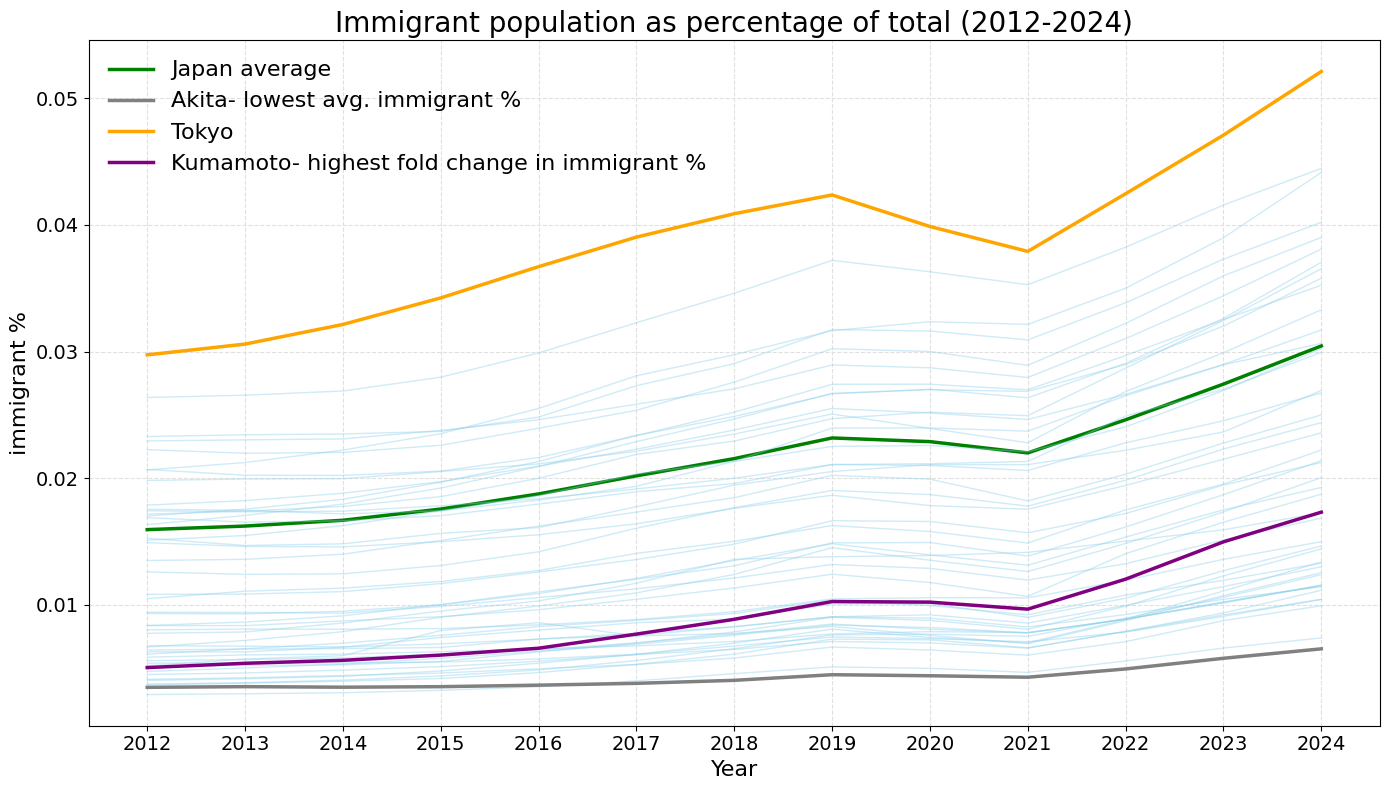

In [ ]:
#make plot to show yearly percent immigrant population by prefecture.
#Highlight a few notable prefectures
fig, ax = plt.subplots(figsize=(14,8))
highlight = ['Japan', 'Tokyo']
for prefecture in immigrant_pop_percent.columns:
    if prefecture == 'Japan':
        ax.plot(
            immigrant_pop_percent.index,
            immigrant_pop_percent[prefecture],
            label = prefecture + ' average',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'green'
        )
    elif prefecture == 'Tokyo':
        ax.plot(
            immigrant_pop_percent.index,
            immigrant_pop_percent[prefecture],
            label = prefecture,
            linewidth = 2.5,
            alpha = 1.0,
            color = 'orange'
        )
    elif prefecture == 'Kumamoto':
        ax.plot(
            immigrant_pop_percent.index,
            immigrant_pop_percent[prefecture],
            label = prefecture + '- highest fold change in immigrant %',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'purple'
        )
    elif prefecture == 'Akita':
        ax.plot(
            immigrant_pop_percent.index,
            immigrant_pop_percent[prefecture],
            label = prefecture + '- lowest avg. immigrant %',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'grey'
        )
    else:
        ax.plot(
            immigrant_pop_percent.index,
            immigrant_pop_percent[prefecture],
            label = '_nolegend',
            linewidth = 1,
            alpha = 0.4,
            color = 'skyblue'
        )
ax.set_title('Immigrant population as percentage of total (2012-2024)', fontsize = 20)
ax.set_xlabel('Year', fontsize = 16)
plt.gca().set_xticklabels([label[:4] for label in immigrant_pop_percent.index])
ax.set_ylabel('immigrant %', fontsize = 16)
ax.legend(loc='upper left', 
          fontsize=16,
          frameon= False)
ax.grid(
    visible=True,      
    which='major',     
    color='#e0e0e0',   
    linestyle='--',     
    linewidth=0.8,     
)
plt.tick_params(axis='both', labelsize=14)
fig.tight_layout()
plt.savefig('../../data/figures/immigrant_pop_percent_2012-2024.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

/var/folders/bc/ckv226vd2r767mrgsjn26yn80000gn/T/ipykernel_99718/682051633.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([label[:4] for label in immigrant_pop_percent.index])


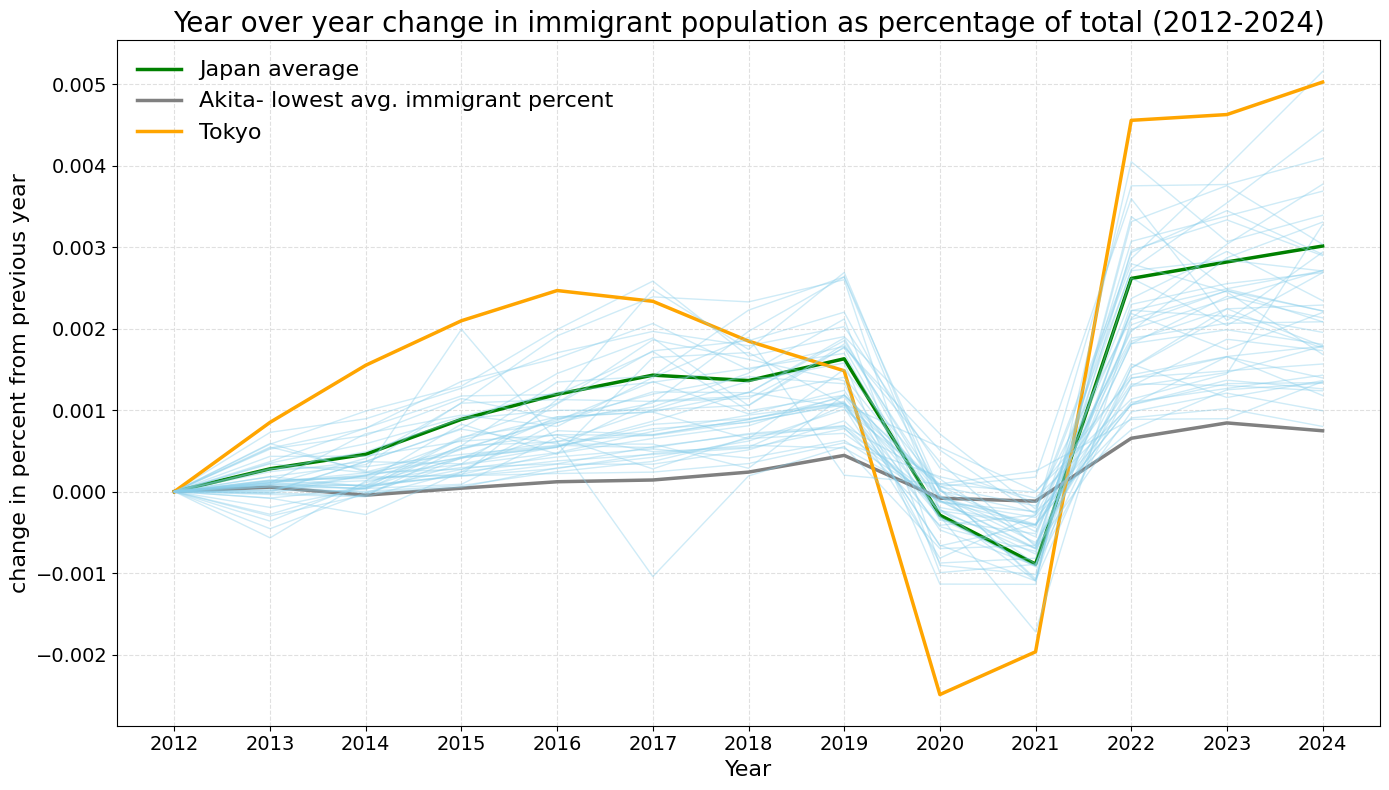

In [ ]:
#make a similar plot for the year over year immigration increase
fig, ax = plt.subplots(figsize=(14,8))
highlight = ['Japan', 'Tokyo']
for prefecture in imm_pop_percent_yearly_inc.columns:
    if prefecture == 'Japan':
        ax.plot(
            imm_pop_percent_yearly_inc.index,
            imm_pop_percent_yearly_inc[prefecture],
            label = prefecture + ' average',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'green'
        )
    elif prefecture == 'Tokyo':
        ax.plot(
            imm_pop_percent_yearly_inc.index,
            imm_pop_percent_yearly_inc[prefecture],
            label = prefecture,
            linewidth = 2.5,
            alpha = 1.0,
            color = 'orange'
        )
    elif prefecture == 'Akita':
        ax.plot(
            imm_pop_percent_yearly_inc.index,
            imm_pop_percent_yearly_inc[prefecture],
            label = prefecture + '- lowest avg. immigrant percent',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'grey'
        )
    else:
        ax.plot(
            imm_pop_percent_yearly_inc.index,
            imm_pop_percent_yearly_inc[prefecture],
            label = '_nolegend',
            linewidth = 1,
            alpha = 0.4,
            color = 'skyblue'
        )
ax.set_title('Year over year change in immigrant population as percentage of total (2012-2024)', fontsize = 20)
ax.set_xlabel('Year', fontsize = 16)
ax.set_ylabel('change in percent from previous year', fontsize = 16)
ax.legend(loc='upper left', 
          fontsize=16,
          frameon= False)
ax.grid(
    visible=True,      
    which='major',     
    color='#e0e0e0',   
    linestyle='--',     
    linewidth=0.8,     
)
plt.gca().set_xticklabels([label[:4] for label in immigrant_pop_percent.index])
plt.tick_params(axis='both', labelsize=14)
fig.tight_layout()
plt.savefig('../../data/figures/year_over_year_imm_pop_change_2012-2024.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

In [12]:
#create map using geopandas to visualize data with map of Japan

geojson_japan = "https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson"
japan_map = gpd.read_file(geojson_japan)
#replace parts of prefecture names to match other dataframes 
japan_map['nam']= [x.replace(' Fu', '').replace(' Ken', '').replace(' To', '').replace('Hokkai Do', 'Hokkaido') for x in japan_map['nam']]


In [13]:
#extract just the immigrant percent in 2024
imm_percent_2024 = immigrant_pop_percent.T.iloc[:,-1]

#merge with the japan map data, merging on 'nam' for the japan_map and the index for the imm_percent_2024
japan_map_immigrant_percent = japan_map.merge(imm_percent_2024, left_on = 'nam', right_index=True)
japan_map_immigrant_percent = japan_map_immigrant_percent.rename(columns = {"2024-01-01":"im_per_2024"})
japan_map_immigrant_percent.head()

,nam,nam_ja,id,geometry,im_per_2024
0,Kyoto,京都府,26,"MULTIPOLYGON (((135.0367 35.53733, 135.0352 35...",0.033299
1,Saga,佐賀県,41,"MULTIPOLYGON (((129.8622 33.58753, 129.8577 33...",0.014414
2,Kumamoto,熊本県,43,"MULTIPOLYGON (((131.1104 33.18313, 131.11479 3...",0.017316
3,Kagawa,香川県,37,"MULTIPOLYGON (((134.332 34.56313, 134.3351 34....",0.021382
4,Aichi,愛知県,23,"MULTIPOLYGON (((136.96091 35.41453, 136.963 35...",0.044468


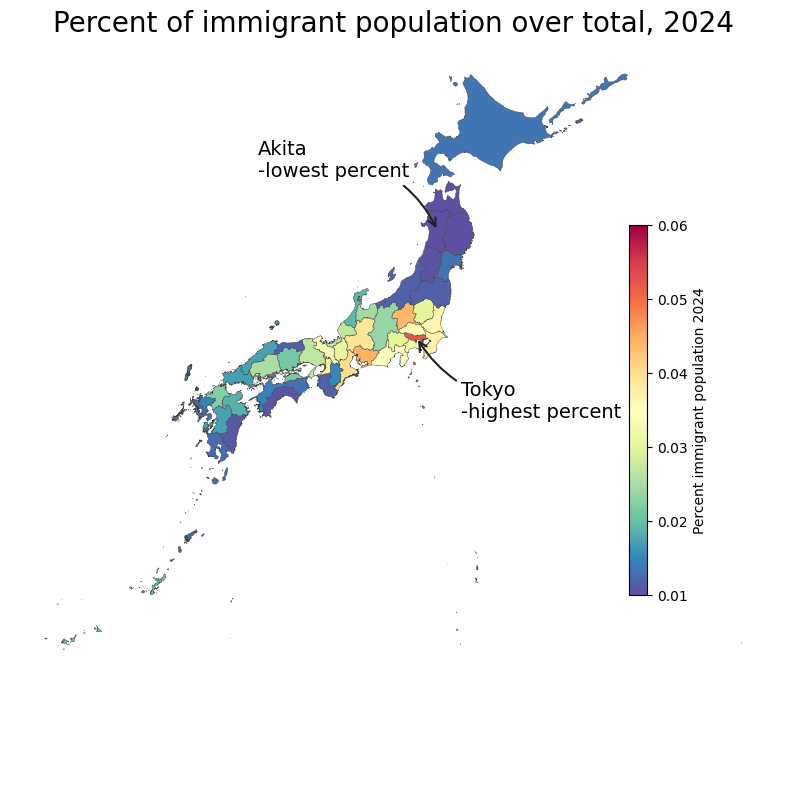

In [ ]:
#define plotting and arrow annotation functions for making maps. 
#create a map with immigant percentage
def plot_japan_map(df:pd.DataFrame, variable:str, legend:str, title:str, c_min:float, c_max:float,ax=None):
    """Plots heatmap of Japan for given column values

    Args:
        df: dataframe to be plotted; requires Japan geometry data
        variable: column for heatmap values
        legend: legend title
        title: plot title
    """
    ax = df.plot(column = variable,
                cmap = 'Spectral_r',
                vmin = c_min,
                vmax = c_max,
                legend=True,
                legend_kwds={
                    'label':legend,
                    'orientation':'vertical',
                    'pad': -0.2,
                    'shrink': 0.5,
                    },
                figsize=(8,8),
                facecolor='#eaeaea',
                edgecolor='#444444',
                linewidth=0.3)
    ax.axis('off')
    ax.set_title(title,
             loc='center',
             fontsize=20,
             color = "#000000")
    plt.tight_layout()
    return ax
      

ax = plot_japan_map(japan_map_immigrant_percent, 'im_per_2024', 'Percent immigrant population 2024', 
                    'Percent of immigrant population over total, 2024', 0.01, 0.06)


def get_x_y(prefecture):
    query = f"nam == '{prefecture}'"
    pt = japan_map_immigrant_percent.query(query)['geometry'].representative_point()
    x = pt.get_coordinates()['x'].values[0]
    y = pt.get_coordinates()['y'].values[0]
    return x, y

tokyo_x, tokyo_y = get_x_y('Tokyo')
akita_x, akita_y = get_x_y('Akita')
kyoto_x, kyoto_y = get_x_y('Kyoto')

def add_arrow_annotation(ax, x, y, label, x_offset, y_offset):
    ax.annotate(
        label,
        xy = (x,y),
        xytext = (x+x_offset, y+y_offset),
        fontsize=14,
        color = '#000000',
        arrowprops=dict(
        arrowstyle="->",                        
        connectionstyle="arc3,rad=-0.3",        
        color="#222222",                        
        lw=1.5                                  
        )
    )

#add_arrow_annotation(ax, kyoto_x, kyoto_y, 'Kyoto', 2, -3)
add_arrow_annotation(ax, tokyo_x, tokyo_y, 'Tokyo\n-highest percent', 2, -3)
add_arrow_annotation(ax, akita_x, akita_y, 'Akita\n-lowest percent', -8, 2)
plt.savefig('../../data/figures/map_2024_imm_percent.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

In [ ]:
total_fold_change = []
for column in immigrant_pop_percent.columns:
    change = immigrant_pop_percent[column].iloc[12]/immigrant_pop_percent[column].iloc[0]
    total_fold_change.append(change)

total_percent_change = []
for column in immigrant_pop_percent.columns:
    change = immigrant_pop_percent[column].iloc[12] - immigrant_pop_percent[column].iloc[0]
    total_percent_change.append(change)

fold_change_to_2022 = []
for column in immigrant_pop_percent.columns:
    change = immigrant_pop_percent[column].iloc[-3]/immigrant_pop_percent[column].iloc[8]
    fold_change_to_2022.append(change)

fold_change_to_2022 = pd.Series(data = fold_change_to_2022, index = immigrant_pop_percent.columns, name = 'imm_fold_change_2022')


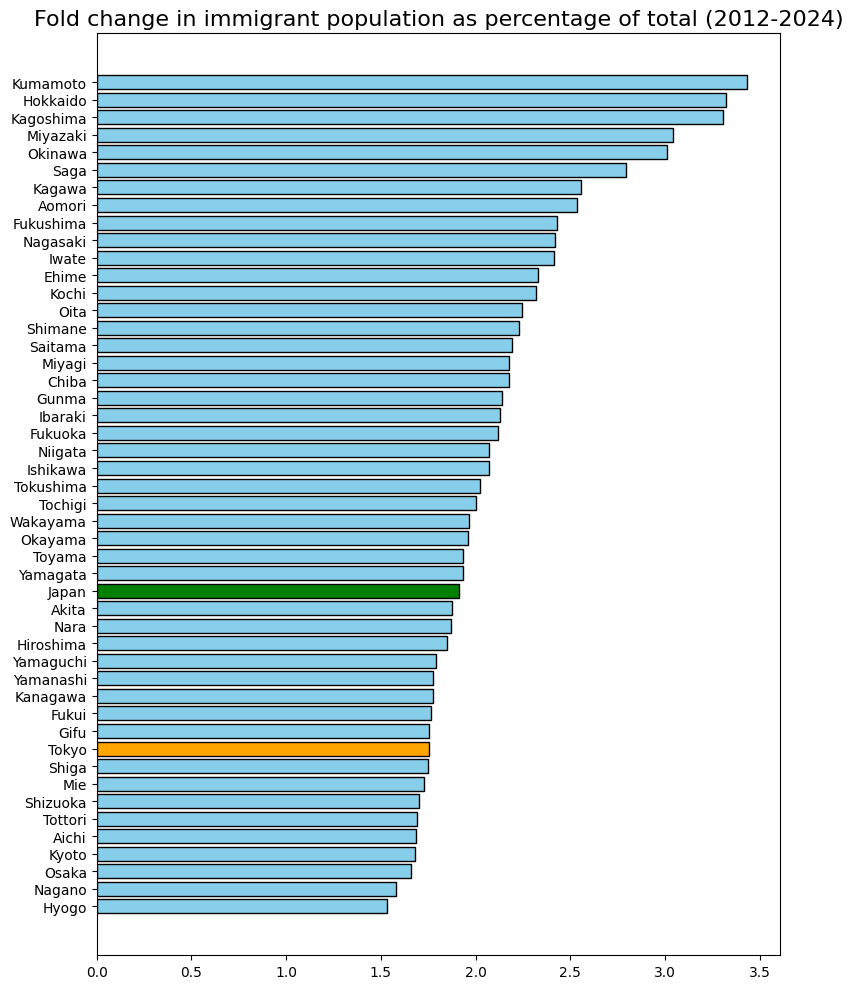

In [ ]:
immigrant_percent_fold_change = pd.Series(total_fold_change, index = immigrant_pop_percent.columns, name = 'imm_fold_change')
immigrant_percent_fold_change.sort_values(inplace=True)

immigrant_total_percent_change = pd.Series(total_percent_change, index = immigrant_pop_percent.columns, name = 'percent_change')

highlight = {'Tokyo':'orange', 'Japan':'green'}
colors = [highlight.get(name, 'skyblue') for name in immigrant_percent_fold_change.index]

fig, ax = plt.subplots(figsize=(8,10))
ax.barh(immigrant_percent_fold_change.index, immigrant_percent_fold_change, color = colors, edgecolor='black')
ax.set_title('Fold change in immigrant population as percentage of total (2012-2024)', fontsize=16)
fig.tight_layout()
plt.show()

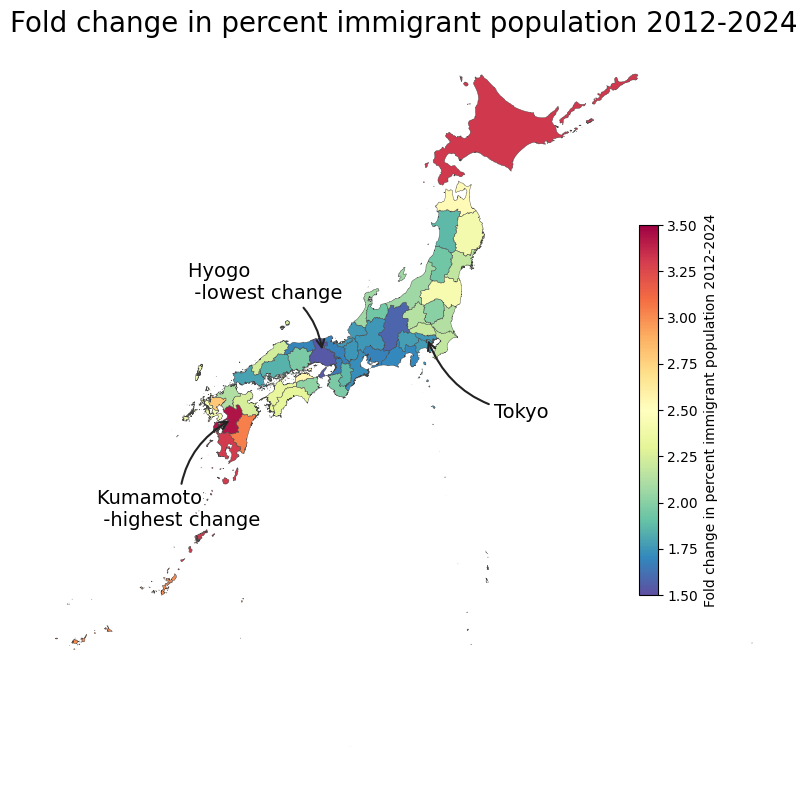

In [17]:
#make a map visualization of the fold change by merging the above data with the japan map data
japan_map_fold_change = japan_map.merge(immigrant_percent_fold_change, left_on='nam', right_index=True)

ax = plot_japan_map(japan_map_fold_change, 'fold_change', 'Fold change in percent immigrant population 2012-2024',
                    'Fold change in percent immigrant population 2012-2024', 1.5, 3.5)

kumamoto_x, kumamoto_y = get_x_y('Kumamoto')
hyogo_x, hyogo_y = get_x_y('Hyogo')
add_arrow_annotation(ax, tokyo_x, tokyo_y, 'Tokyo', 3, -3)
add_arrow_annotation(ax, kumamoto_x, kumamoto_y, 'Kumamoto \n -highest change', -6, -4)
add_arrow_annotation(ax, hyogo_x, hyogo_y, 'Hyogo \n -lowest change', -6, 2)
plt.savefig('../../data/figures/map_foldchange_imm_percent_2012-2024.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

In [18]:
#read in 2024 and 2026 hor election results and extract the sanseito vote percent data by prefecture
hor_2024 = pd.read_csv("../../data/clean/election_results/house_of_representatives_20241027_vote_percent")
hor_2024.set_index('prefecture', inplace=True)
sanseito_2024 = pd.Series(hor_2024['Sanseito'], name = 'sanseito_2024')

hor_2026 = pd.read_csv("../../data/clean/election_results/house_of_representatives_20260208_vote_percent")
hor_2026.set_index('prefecture', inplace=True)
sanseito_2026 = pd.Series(hor_2026['Sanseito'], name = 'sanseito_2026')

#turn means from above into a pd data series
means_series = pd.Series(means, name = 'mean_immigrant_percent')

In [ ]:
#read in hoc 2022 and 2025 data as well
hoc_2022 = pd.read_csv("../../data/clean/election_results/house_of_councillors_20220710_vote_percent")
hoc_2022 = hoc_2022.set_index('prefecture')
hoc_2025 = pd.read_csv("../../data/clean/election_results/house_of_councillors_20250720_vote_percent")
hoc_2025 = hoc_2025.rename(columns = {'Unnamed: 0':'prefecture'})
hoc_2025 = hoc_2025.set_index('prefecture')
sanseito_2022 = pd.Series(hoc_2022['Sanseito'], name = 'sanseito_2022')
sanseito_2025 = pd.Series(hoc_2025['Sanseito'], name = 'sanseito_2025')

,Liberal Democratic Party,Constitutional Democratic Party,Japan Innovation Party,Komeito,Democratic Party For the People,Japanese Communist Party,Reiwa Shinsengumi,Sanseito,Conservative Party of Japan,Social Democratic Party,Independent Alliance,Team Mirai,Nippon Seishinkai,Nihon Kakumeito,Saisei no Michi,NHK Party
prefecture,,,,,,,,,,,,,,,,
Hokkaido,0.245871,0.173886,0.029706,0.086270,0.114616,0.058071,0.074575,0.108334,0.047975,0.018551,0.003933,0.016368,0.004508,0.001092,0.006660,0.009584
Aomori,0.290070,0.193622,0.021894,0.074452,0.097499,0.054439,0.073477,0.113479,0.034154,0.016833,0.003015,0.008720,0.003435,0.000692,0.005617,0.008600
Iwate,0.236920,0.227293,0.028943,0.062668,0.110104,0.048590,0.075909,0.115405,0.032475,0.025644,0.002759,0.011988,0.003524,0.000702,0.006494,0.010584
Miyagi,0.244567,0.163105,0.037030,0.079382,0.114283,0.043920,0.083955,0.112561,0.046384,0.020477,0.003188,0.028484,0.004342,0.001033,0.007325,0.009963
Akita,0.354435,0.136861,0.032574,0.072441,0.120267,0.035701,0.059734,0.093902,0.036314,0.027523,0.003900,0.008732,0.002752,0.000637,0.005561,0.008664


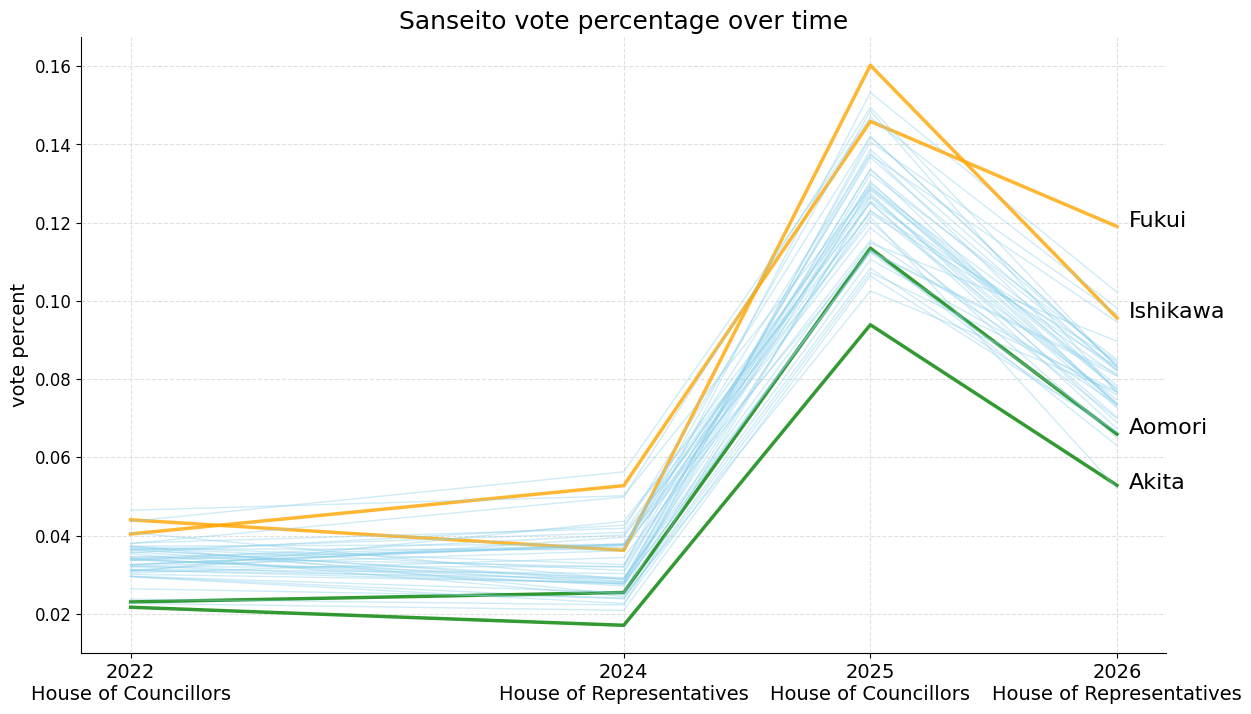

In [ ]:
#create a dataframe with the merged sanseito vote totals for the four elections
sanseito_vote_totals = pd.merge(sanseito_2022, sanseito_2024, left_index = True, right_index=True)
sanseito_vote_totals = pd.merge(sanseito_vote_totals, sanseito_2025, right_index=True, left_index=True)
sanseito_vote_totals = pd.merge(sanseito_vote_totals, sanseito_2026, right_index=True, left_index=True)

#plot the sanseito vote percentage over time
fig, ax = plt.subplots(figsize=(14,8))
for prefecture in sanseito_vote_totals.index:
    if prefecture in ['Fukui', 'Ishikawa']:
        ax.plot(
        [2022,2024,2025,2026],
        sanseito_vote_totals.loc[prefecture],
        #label = prefecture + ' average',
        linewidth = 2.5,
        alpha = 0.8,
        color = 'orange'
        )
    elif prefecture in ['Akita', 'Aomori']:
        ax.plot(
        [2022,2024,2025,2026],
        sanseito_vote_totals.loc[prefecture],
        #label = prefecture + ' average',
        linewidth = 2.5,
        alpha = 0.8,
        color = 'green'
        )
    
    else:
        ax.plot(
        [2022,2024,2025,2026],
        sanseito_vote_totals.loc[prefecture],
        label = '_nolegend',
        linewidth = 1,
        alpha = 0.4,
        color = 'skyblue'
        )
plt.text(x=2026.05, y = 0.051839, s = 'Akita', fontsize = 16)
plt.text(x=2026.05, y = 0.119038 , s = 'Fukui', fontsize = 16)
plt.text(x=2026.05, y = 0.095632 , s = 'Ishikawa', fontsize = 16)
plt.text(x=2026.05, y = 0.065919 , s = 'Aomori', fontsize = 16)
plt.xticks(ticks = [2022, 2024, 2025, 2026],
           labels = ['2022\nHouse of Councillors', 
                     '2024\nHouse of Representatives',
                     '2025\nHouse of Councillors',
                     '2026\nHouse of Representatives'],
            fontsize = 14
)
plt.yticks(fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(
    visible=True,      
    which='major',     
    color='#e0e0e0',   
    linestyle='--',     
    linewidth=0.8,     
)
ax.set_ylabel('vote percent', fontsize = 14)
plt.title('Sanseito vote percentage over time', fontsize = 18)
plt.savefig('../../data/figures/sanseito_vote_percent_over_time.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

In [ ]:
#add various immigration data to the sanseito vote totals dataframe
imm_percent_2024 = pd.Series(immigrant_pop_percent.iloc[-1], name = 'imm_percent_2024')
imm_percent_2022 = pd.Series(immigrant_pop_percent.iloc[-3], name = 'imm_percent_2022')
imm_percent_change = pd.Series(immigrant_pop_percent.iloc[-1] - immigrant_pop_percent.iloc[0], name = 'imm_percent_change_2012-2024')
imm_percent_change_2022 = pd.Series(immigrant_pop_percent.iloc[-3] - immigrant_pop_percent.iloc[0], name = 'imm_percent_change_2012-2022')
sanseito_vote_totals = pd.merge(sanseito_vote_totals, imm_percent_2024, left_index = True, right_index=True)
sanseito_vote_totals = pd.merge(sanseito_vote_totals, imm_percent_2022, left_index = True, right_index=True)
sanseito_vote_totals = pd.merge(sanseito_vote_totals, imm_percent_change, left_index = True, right_index=True)
sanseito_vote_totals = pd.merge(sanseito_vote_totals, imm_percent_change_2022, left_index = True, right_index=True)

,sanseito_2022,sanseito_2024,sanseito_2025,sanseito_2026,imm_percent_2024,imm_percent_2022,imm_percent_change_2012-2024,imm_percent_change_2012-2022
prefecture,,,,,,,,
Akita,0.021664,0.017053,0.093902,0.052839,0.006523,0.004934,0.003040,0.001452
Yamagata,0.022650,0.020891,0.106357,0.066531,0.010420,0.007841,0.005031,0.002451
Aomori,0.023020,0.025434,0.113479,0.065919,0.007385,0.005566,0.004473,0.002655
Fukushima,0.023724,0.022270,0.126584,0.072690,0.011487,0.008859,0.006756,0.004128
Niigata,0.026397,0.024055,0.110591,0.075937,0.011569,0.008875,0.005980,0.003286
Shimane,0.029441,0.022629,0.107292,0.076938,0.017273,0.015029,0.009524,0.007280
Hokkaido,0.029528,0.023808,0.108334,0.066304,0.013382,0.008850,0.009351,0.004820
Ibaraki,0.029595,0.025482,0.141955,0.083421,0.036546,0.028689,0.019389,0.011532
Tochigi,0.030095,0.028021,0.132398,0.085011,0.030230,0.024053,0.015126,0.008950


In [ ]:
sanseito_vote_totals = pd.merge(sanseito_vote_totals, immigrant_percent_fold_change, left_index = True, right_index=True)
sanseito_vote_totals = pd.merge(sanseito_vote_totals, fold_change_to_2022, left_index = True, right_index=True)
sanseito_vote_totals['percent_change_2022-2024'] = sanseito_vote_totals['imm_percent_2024'] - sanseito_vote_totals['imm_percent_2022']



,sanseito_2022,sanseito_2024,sanseito_2025,sanseito_2026,imm_percent_2024,imm_percent_2022,imm_percent_change_2012-2024,imm_percent_change_2012-2022,imm_fold_change,imm_fold_change_2022
prefecture,,,,,,,,,,
Hokkaido,0.029528,0.023808,0.108334,0.066304,0.013382,0.008850,0.009351,0.004820,3.320066,1.194057
Aomori,0.023020,0.025434,0.113479,0.065919,0.007385,0.005566,0.004473,0.002655,2.536677,1.117789
Iwate,0.030461,0.034376,0.115405,0.073531,0.009927,0.007091,0.005813,0.002977,2.413289,1.102983
Miyagi,0.031196,0.027660,0.112561,0.080790,0.013291,0.010775,0.007188,0.004672,2.177752,1.083662
Akita,0.021664,0.017053,0.093902,0.052839,0.006523,0.004934,0.003040,0.001452,1.872986,1.121937


In [65]:
merged = pd.merge(immigrant_percent_fold_change, sanseito_2024, left_index = True, right_index = True )
merged = pd.merge(merged, sanseito_2026, left_index = True, right_index = True )
merged = pd.merge(merged, means_series, left_index = True, right_index = True)
merged = pd.merge(merged, imm_percent_2024, left_index=True, right_index=True)
merged = pd.merge(merged, imm_percent_change, left_index=True, right_index=True)

In [66]:
#calculate fold change and percent change in sanseito vote share from 2024 to 2026
merged['sanseito_fold_change'] = merged['sanseito_2026'] / merged['sanseito_2024']
merged['percent_change'] = merged['sanseito_2026'] - merged['sanseito_2024']

merged.sort_values(by='sanseito_2026').head()

,fold_change,sanseito_2024,sanseito_2026,mean_immigrant_percent,imm_percent_2024,imm_percent_change_2012-2024,sanseito_fold_change,percent_change
Nara,1.867698,0.036377,0.052072,0.010085,0.014986,0.006962,1.431446,0.015695
Akita,1.872986,0.017053,0.052839,0.004302,0.006523,0.003040,3.098528,0.035786
Tokyo,1.752469,0.037415,0.062998,0.038860,0.052119,0.022379,1.683773,0.025583
Kyoto,1.679790,0.040165,0.064955,0.023756,0.033299,0.013476,1.617192,0.024790
Aomori,2.536677,0.025434,0.065919,0.004503,0.007385,0.004473,2.591707,0.040484


In [264]:
sanseito_vote_totals.describe()

,sanseito_2022,sanseito_2024,sanseito_2025,sanseito_2026
count,47.000000,47.000000,47.000000,47.000000
mean,0.033633,0.033262,0.126914,0.078255
std,0.005204,0.008649,0.014281,0.012150
min,0.021664,0.017053,0.093902,0.052072
25%,0.031051,0.027614,0.115126,0.071441
50%,0.033790,0.031995,0.126955,0.076938
75%,0.036563,0.037759,0.136974,0.083216
max,0.046459,0.056296,0.160259,0.119038


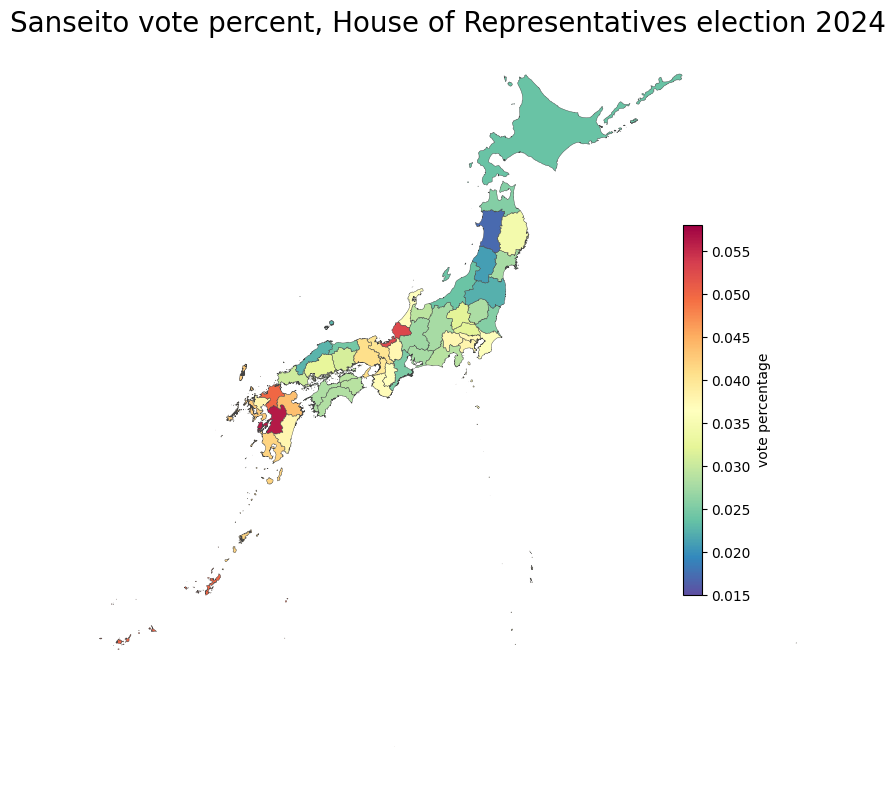

In [265]:
#merge sanseito vote data with map data
#japan_map_sanseito = japan_map.merge(sanseito_vote_totals, left_on = 'nam', right_index=True)
#japan_map_sanseito.head()
akita_x, akita_y = get_x_y('Akita')
sanseito_2024_map = plot_japan_map(japan_map_sanseito, 'sanseito_2024', 'vote percentage', 'Sanseito vote percent, House of Representatives election 2024', 0.015, 0.058)
#add_arrow_annotation(sanseito_2024_map, kumamoto_x, kumamoto_y, 'Kumamoto \n -highest vote percentage', -6, -4)
#add_arrow_annotation(sanseito_2024_map, akita_x, akita_y, 'Akita \n -lowest vote percentage', -12, 2)
plt.savefig('../../data/figures/map_sanseito_hor_2024_vote_percent.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

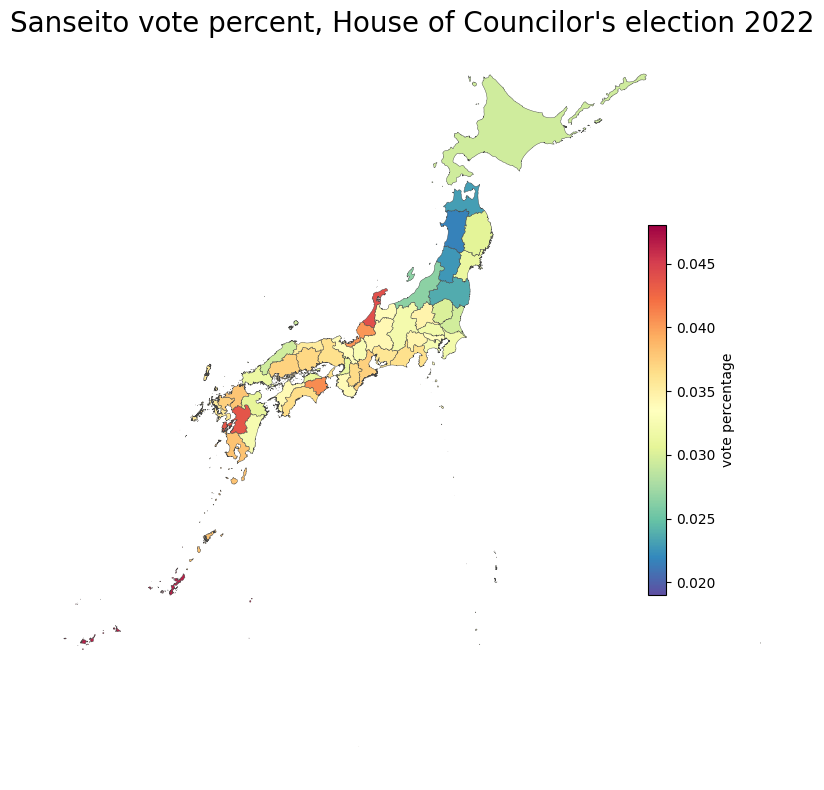

In [ ]:
#merge sanseito vote data with map data
japan_map_sanseito = japan_map.merge(sanseito_vote_totals, left_on = 'nam', right_index=True)

akita_x, akita_y = get_x_y('Akita')
sanseito_2022_map = plot_japan_map(japan_map_sanseito, 'sanseito_2022', 'vote percentage', 'Sanseito vote percent, House of Councilor\'s election 2022', 0.019, 0.048)
#add_arrow_annotation(sanseito_2024_map, kumamoto_x, kumamoto_y, 'Kumamoto \n -highest vote percentage', -6, -4)
#add_arrow_annotation(sanseito_2024_map, akita_x, akita_y, 'Akita \n -lowest vote percentage', -12, 2)
plt.savefig('../../data/figures/map_sanseito_hoc_2022_vote_percent.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

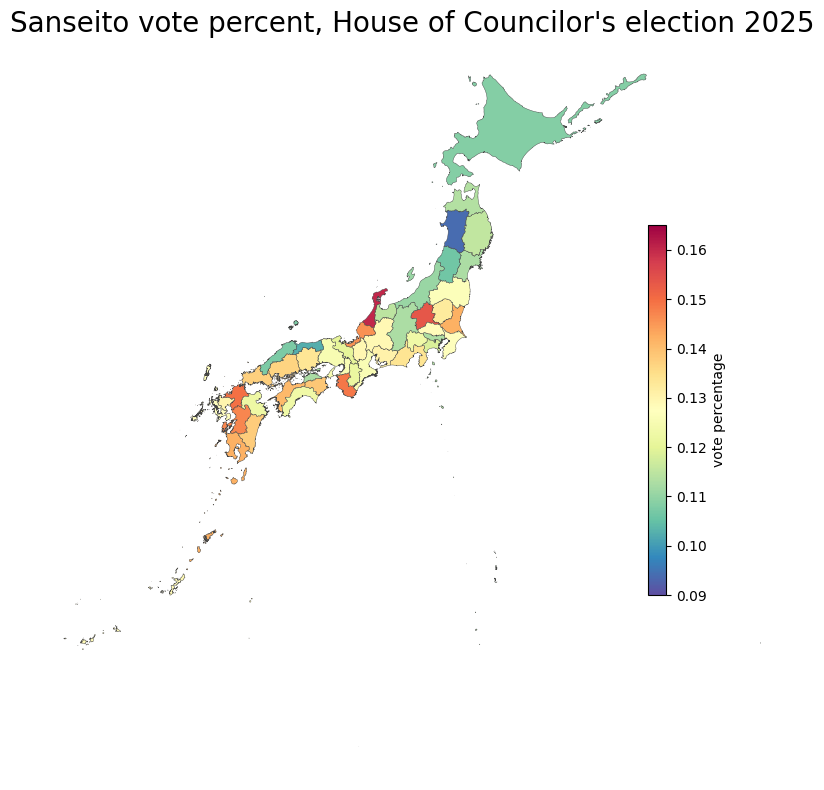

In [267]:
#merge sanseito vote data with map data
#japan_map_sanseito = japan_map.merge(sanseito_vote_totals, left_on = 'nam', right_index=True)
#japan_map_sanseito.head()
akita_x, akita_y = get_x_y('Akita')
sanseito_2025_map = plot_japan_map(japan_map_sanseito, 'sanseito_2025', 'vote percentage', 'Sanseito vote percent, House of Councilor\'s election 2025', 0.09, 0.165)
#add_arrow_annotation(sanseito_2024_map, kumamoto_x, kumamoto_y, 'Kumamoto \n -highest vote percentage', -6, -4)
#add_arrow_annotation(sanseito_2024_map, akita_x, akita_y, 'Akita \n -lowest vote percentage', -12, 2)
plt.savefig('../../data/figures/map_sanseito_hoc_2025_vote_percent.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

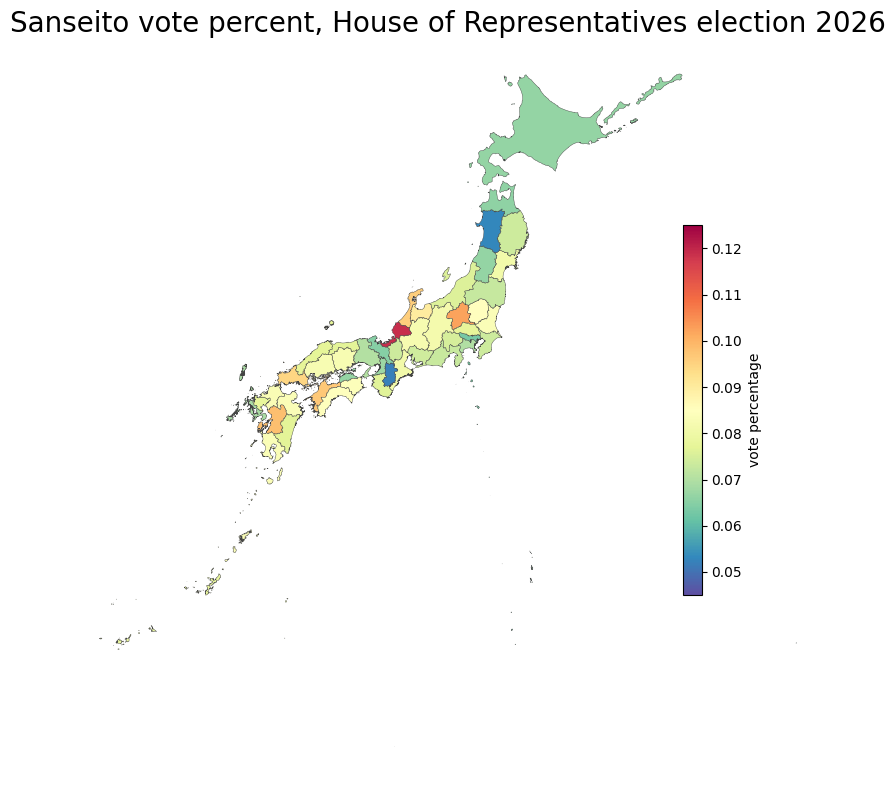

In [268]:
sanseito_2026_map = plot_japan_map(japan_map_sanseito, 'sanseito_2026', 'vote percentage', 
                                   'Sanseito vote percent, House of Representatives election 2026', 0.045, 0.125)
fukui_x, fukui_y = get_x_y('Fukui')
nara_x, nara_y = get_x_y('Nara')
#add_arrow_annotation(sanseito_2026_map, fukui_x, fukui_y, 'Fukui \n -highest vote percentage', -10, 4)
#add_arrow_annotation(sanseito_2026_map, nara_x, nara_y, 'Nara \n -lowest vote percentage', -2, -5)
plt.savefig('../../data/figures/map_sanseito_hor_2026_vote_percent.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)


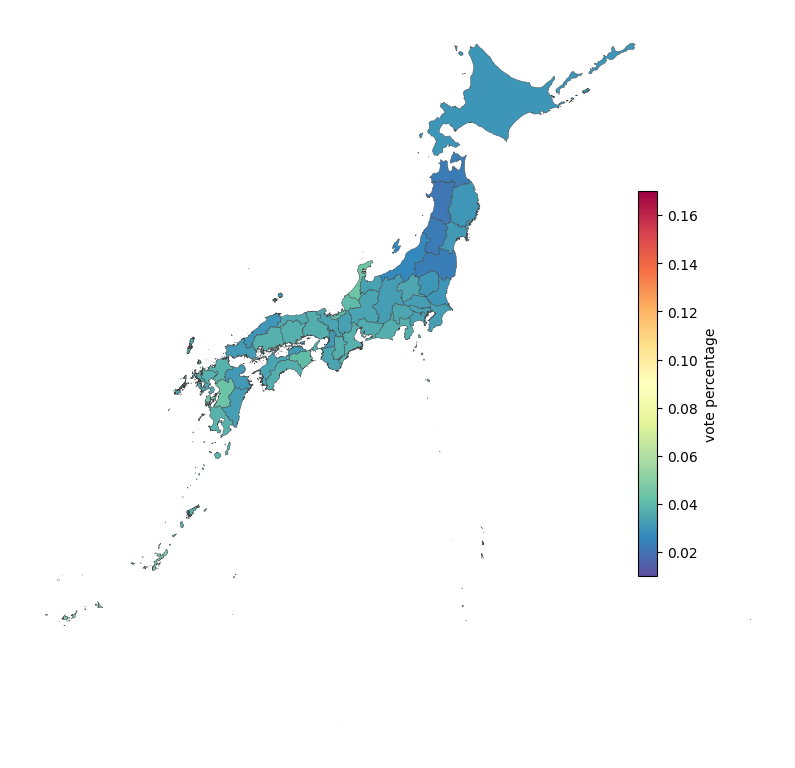

In [167]:
##make plain maps 
plain_2022 = plot_japan_map(japan_map_sanseito, 'sanseito_2022', 'vote percentage', 
                                   '', 0.01, 0.17)
plt.savefig('../../data/figures/plain_map_sanseito_2022.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

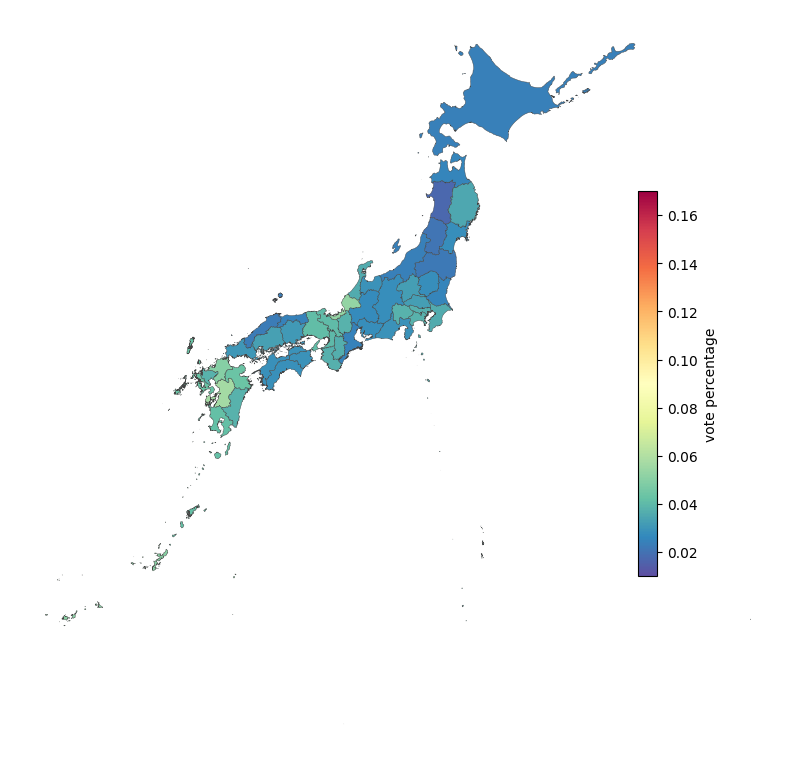

In [168]:
plain_2024 = plot_japan_map(japan_map_sanseito, 'sanseito_2024', 'vote percentage', 
                                   '', 0.01, 0.17)
plt.savefig('../../data/figures/plain_map_sanseito_2024.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

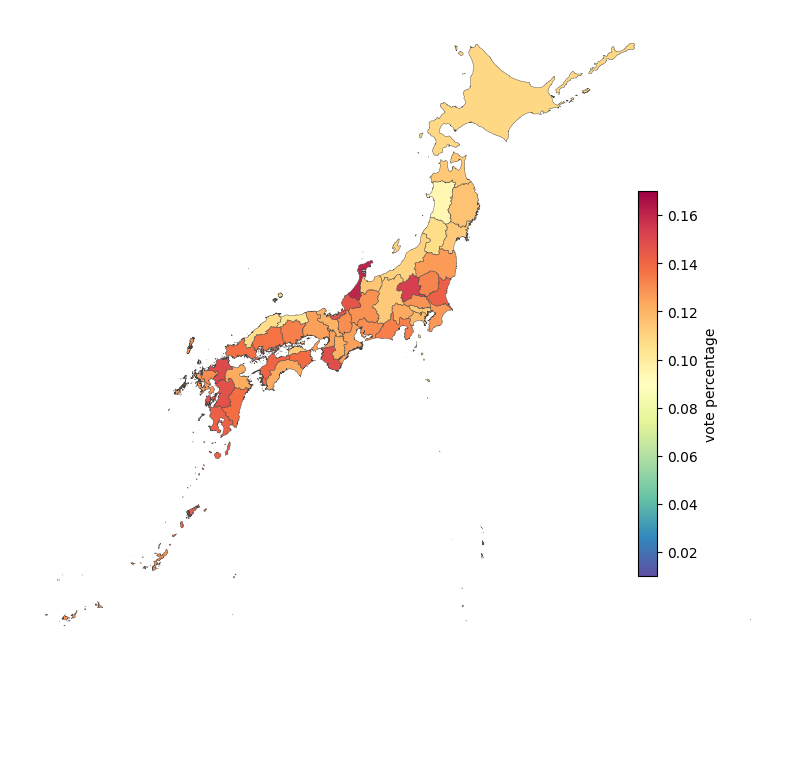

In [169]:
plain_2025 = plot_japan_map(japan_map_sanseito, 'sanseito_2025', 'vote percentage', 
                                   '', 0.01, 0.17)
plt.savefig('../../data/figures/plain_map_sanseito_2025.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

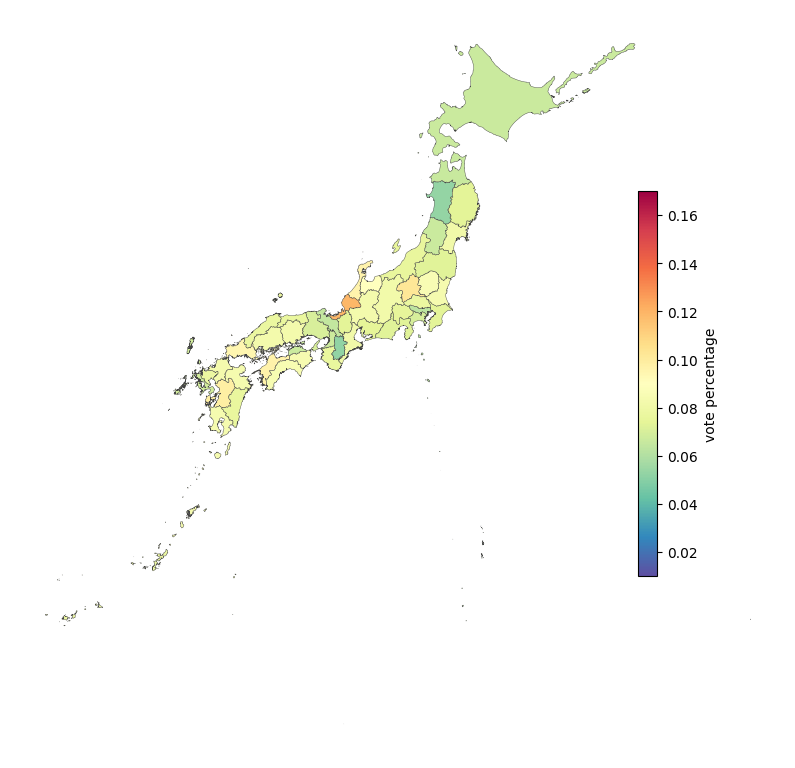

In [170]:
plain_2026 = plot_japan_map(japan_map_sanseito, 'sanseito_2026', 'vote percentage', 
                                   '', 0.01, 0.17)
plt.savefig('../../data/figures/plain_map_sanseito_2026.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

In [ ]:
#function for calculating simple linear fit
def calc_fit(df, x_var, y_var):
    X_real = df[x_var]
    Y_real = df[y_var]
    X_real_const = sm.add_constant(X_real)
    model_real = sm.OLS(Y_real, X_real_const).fit()
    return model_real

#function for plotting regression line and scatter plot
def regression_plot(df, x_var, y_var, line_label_x, line_label_y, title, xlab, ylab):
    model_fit = calc_fit(df, x_var, y_var)
    intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
    r_squared = model_fit.rsquared
    p_value = model_fit.pvalues[x_var]
    line_label = f'R2 ={r_squared: .2}\np ={p_value: .4}'

    fig, ax = plt.subplots(figsize = (8,5.5), layout = 'constrained')
    ax.scatter(df[x_var], df[y_var], 
           alpha=0.7,
           edgecolors='#222222',
           s=75)
    
    ax.plot(df[x_var], intercept + slope * df[x_var], color ='#D05A3F')
    plt.text(line_label_x, line_label_y, line_label, fontsize =14)
    plt.tick_params(axis='both', labelsize=12)
    ax.set_title(title, fontsize = 18)
    ax.set_xlabel(xlab, fontsize = 14)
    ax.set_ylabel(ylab, fontsize = 14)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', color='#cccccc', alpha=0.5, zorder=0)
    return ax

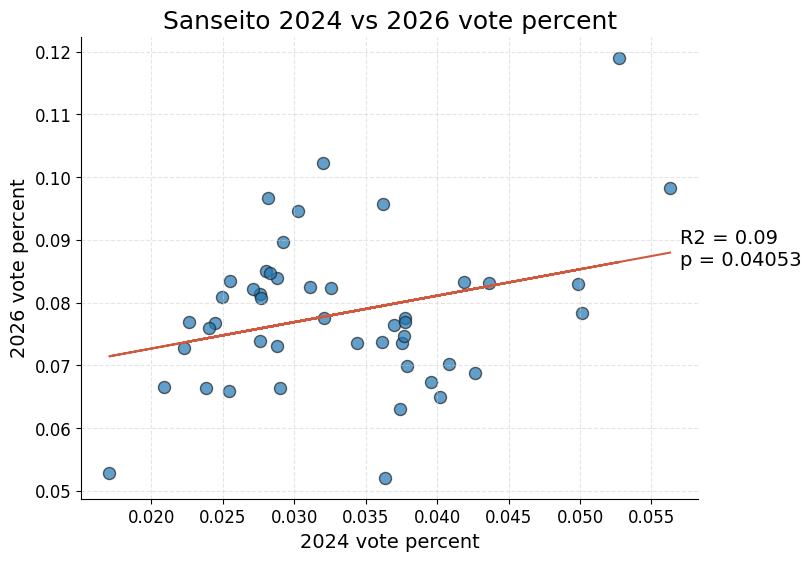

In [123]:
sanseito_2024_vs_2026 = regression_plot(merged, 'sanseito_2024', 'sanseito_2026', 0.057, 0.086, 
                                        'Sanseito 2024 vs 2026 vote percent', '2024 vote percent', '2026 vote percent')

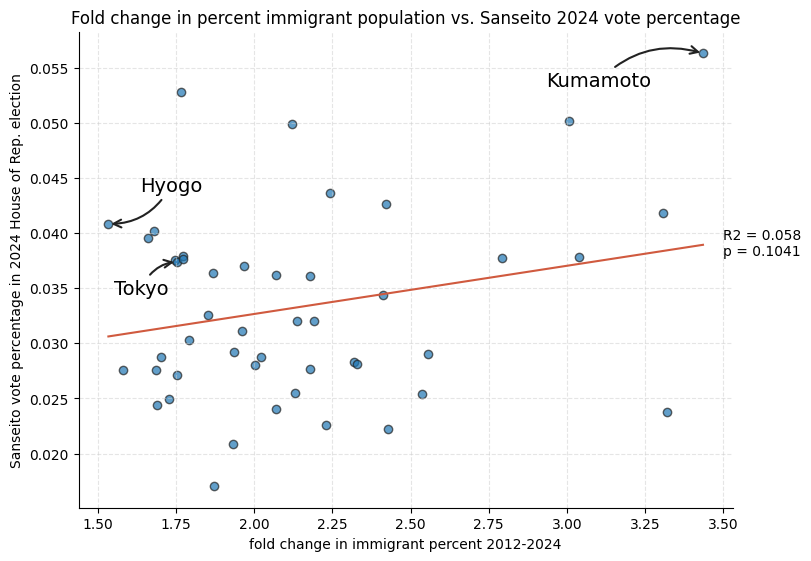

In [62]:
model_fit = calc_fit(merged, 'fold_change', 'sanseito_2024')
intercept, slope = model_fit.params.iloc[0], model_fit.params.iloc[1]
r_squared = model_fit.rsquared
p_value = model_fit.pvalues['fold_change']

line_label = f'R2 ={r_squared: .2}\np ={p_value: .4}'

fig, ax = plt.subplots(figsize = (8,5.5), layout = 'constrained')
ax.scatter(merged['fold_change'], merged['sanseito_2024'], 
           alpha=0.7,
           edgecolors='#222222')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', color='#cccccc', alpha=0.5, zorder=0)

ax.set_title('Fold change in percent immigrant population vs. Sanseito 2024 vote percentage')
ax.set_xlabel('fold change in immigrant percent 2012-2024')
ax.set_ylabel('Sanseito vote percentage in 2024 House of Rep. election')

ax.plot(merged['fold_change'], intercept + slope * merged['fold_change'], color ='#D05A3F')
plt.text(3.5, 0.038, line_label)


kumamoto_x = merged.loc['Kumamoto']['fold_change']
kumamoto_y = merged.loc['Kumamoto']['sanseito_2024']
tokyo_x = merged.loc['Tokyo']['fold_change']
tokyo_y = merged.loc['Tokyo']['sanseito_2024']
hyogo_x = merged.loc['Hyogo']['fold_change']
hyogo_y = merged.loc['Hyogo']['sanseito_2024']
add_arrow_annotation(ax, kumamoto_x, kumamoto_y, 'Kumamoto', -0.5, -0.003)
add_arrow_annotation(ax, tokyo_x, tokyo_y, 'Tokyo', -0.2, -0.003)
add_arrow_annotation(ax, hyogo_x, hyogo_y, 'Hyogo', 0.1, 0.003)




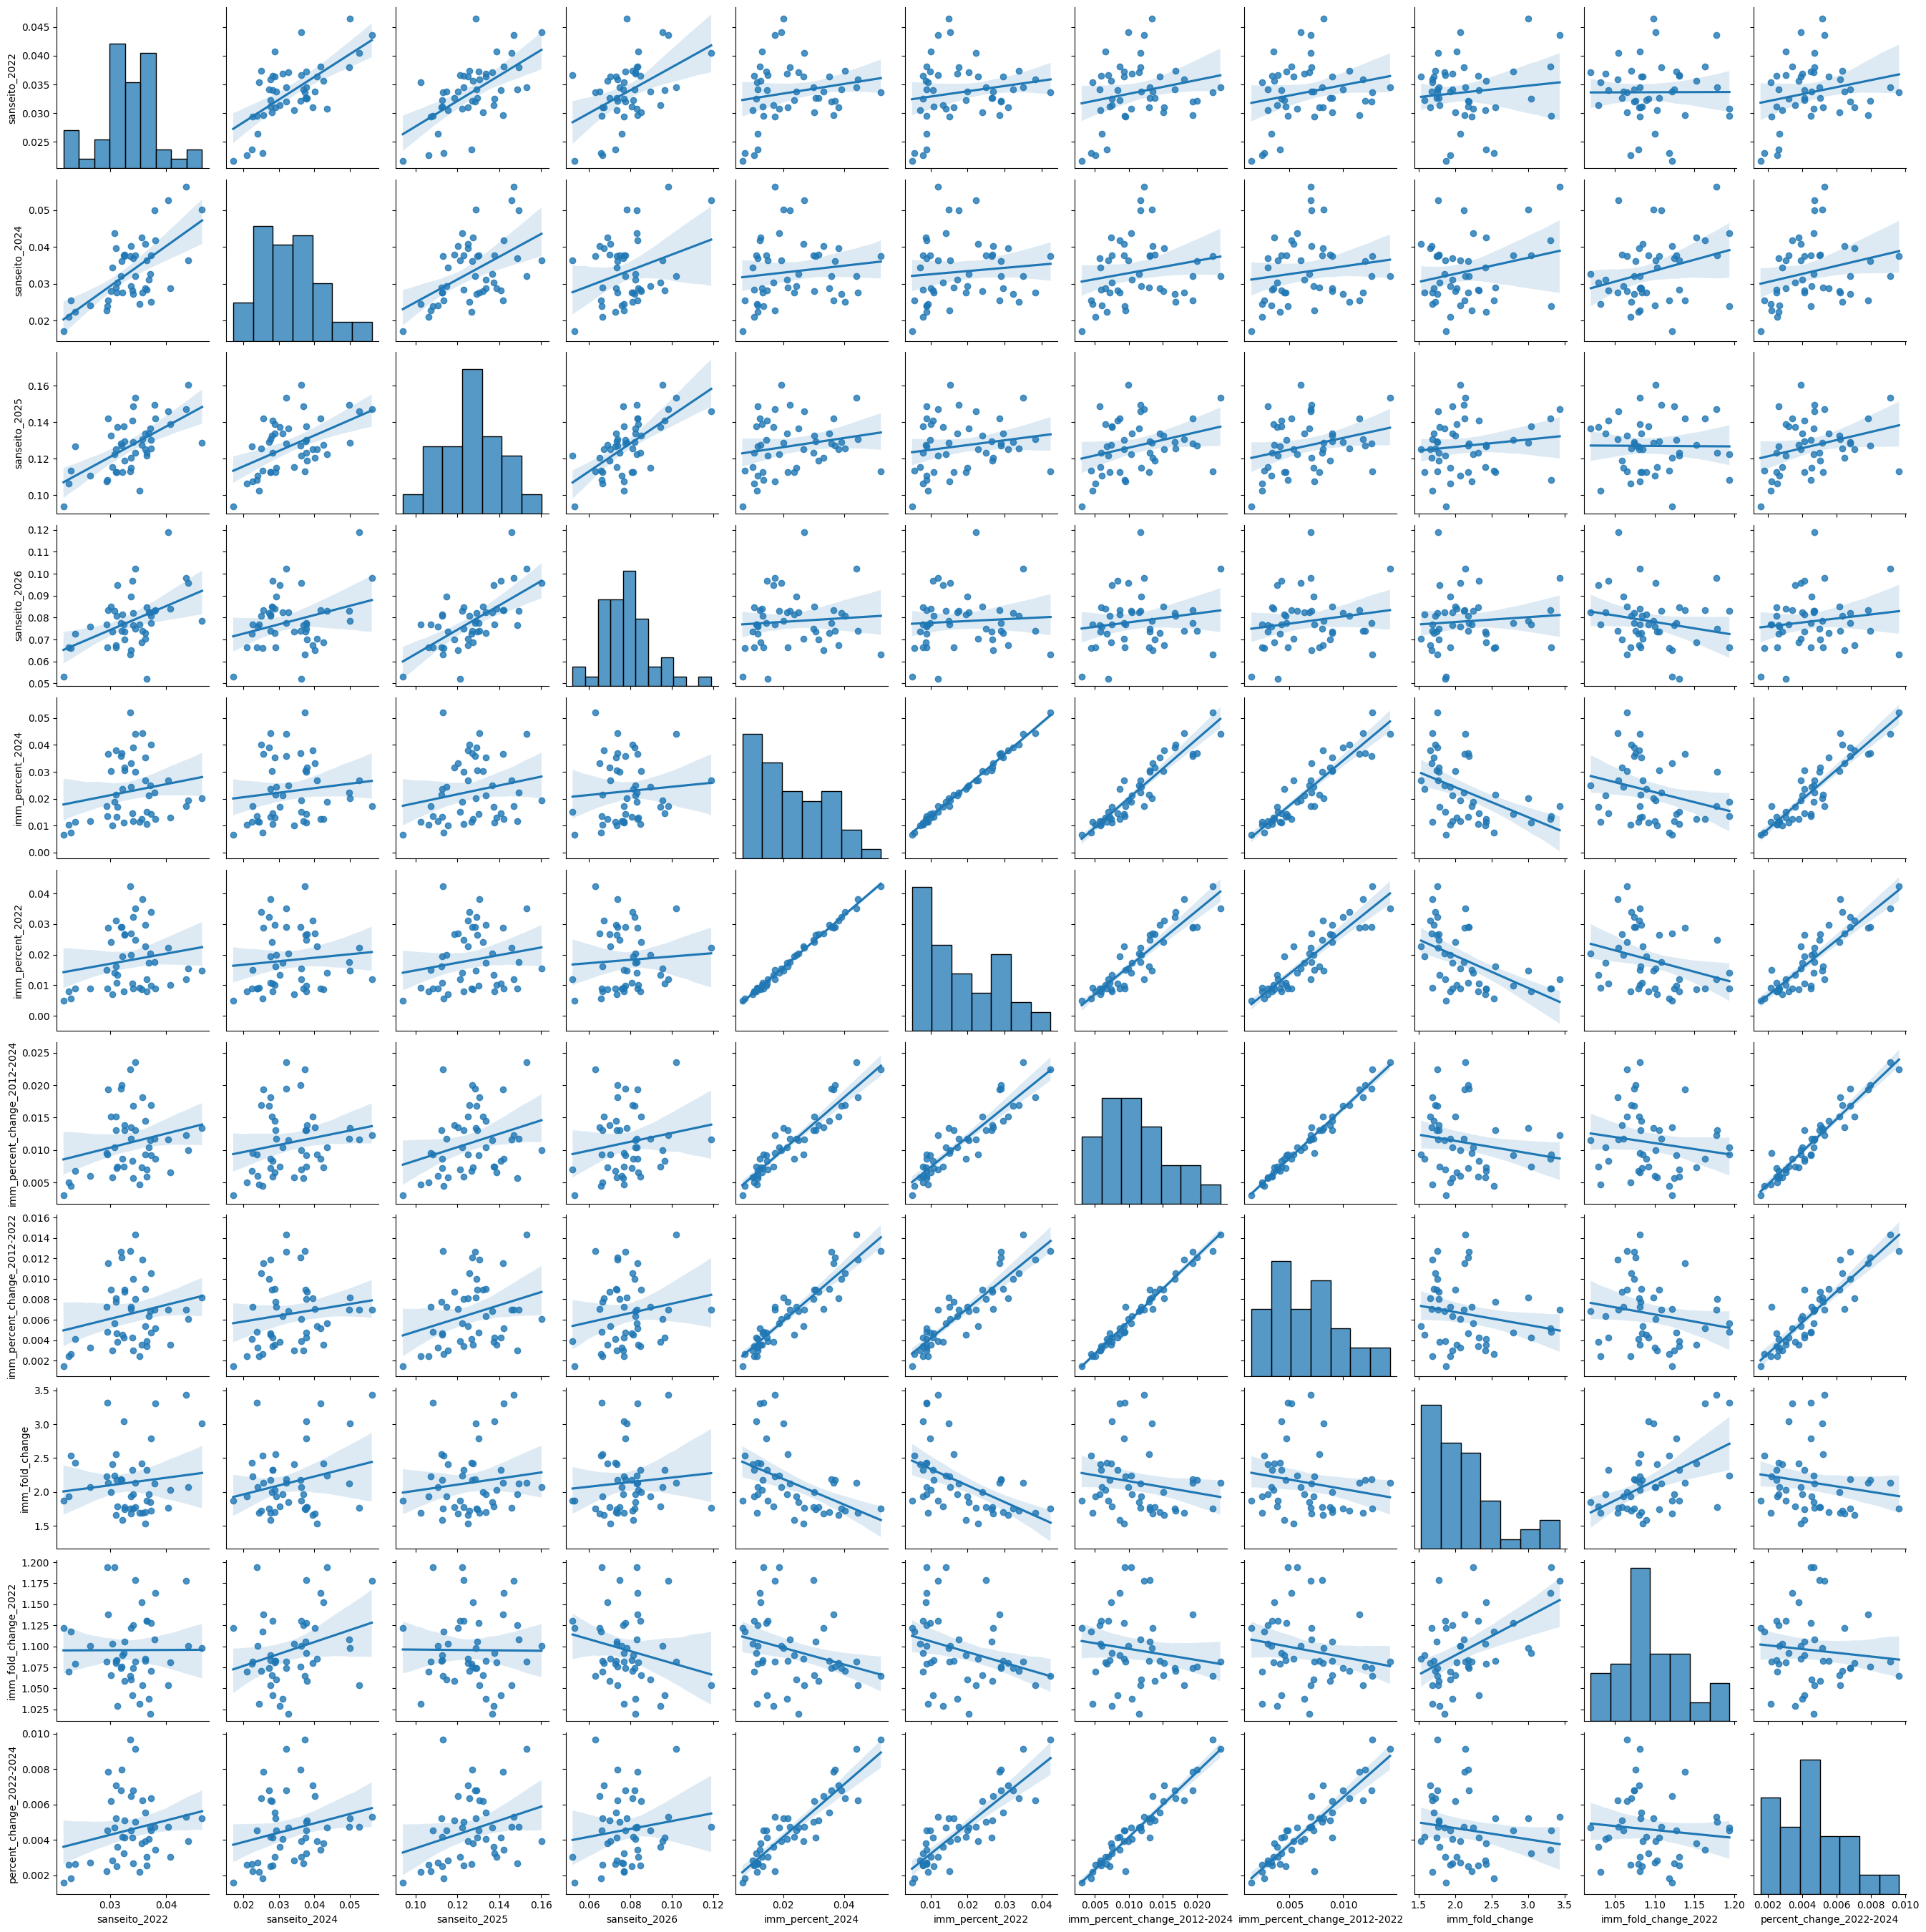

In [ ]:
#seaborn pairplot to quickly visualize relationship between different variables
sns.pairplot(sanseito_vote_totals, kind = 'reg')

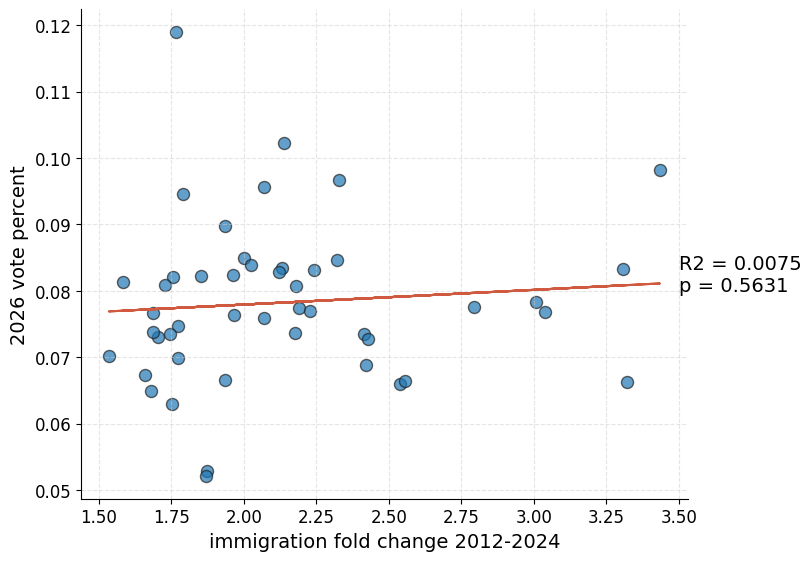

In [ ]:
# use this cell to iterate through desired regression plots
y_columns = ['sanseito_2022', 'sanseito_2024', 'sanseito_2025', 'sanseito_2026']
x_columns = ['imm_percent_2024', 'imm_percent_change_2012-2024', 'fold_change']


fold_change_vs_2026 = regression_plot(sanseito_vote_totals, 'imm_fold_change', 'sanseito_2026', 3.5, .08, 
                                        '', 'immigration fold change 2012-2024', '2026 vote percent')
plt.savefig('../../data/figures/regression_imm_fold_change_2012-2024_vs_2026.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)